# 스마트 창고 출고 지연 예측 — Model v6 (Optuna 재튜닝)

**v5 대비 변경 사항:**
- 타겟 lag 피처가 포함된 새 피처셋에 맞게 Optuna 하이퍼파라미터 재최적화
- v2 params는 190개 피처 기준이었으나 v5/v6는 196개 피처 (타겟 lag 6개 추가)
- Autoregressive test 추론 동일하게 적용

## 0. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

SEED       = 42
N_FOLD     = 5
N_STEPS    = 25
TARGET     = 'avg_delay_minutes_next_30m'
ID_COLS    = ['ID', 'layout_id', 'scenario_id']
N_TRIALS   = 50   # 시간 여유 있으면 100으로 늘려도 됨
TUNE_FOLDS = 3    # 튜닝용 경량 CV

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 1. 데이터 로드 및 전처리

In [2]:
train  = pd.read_csv('./open/train.csv')
test   = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout,  on='layout_id', how='left')

le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'].astype(str))
test['layout_type']  = le.transform(test['layout_type'].astype(str))

train = train.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)
test  = test.sort_values(['scenario_id',  'shift_hour']).reset_index(drop=True)

print(f'train: {train.shape} / test: {test.shape}')

train: (250000, 108) / test: (50000, 107)


In [3]:
ts_features = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m',  'loading_dock_util', 'battery_mean',
    'blocked_path_15m', 'task_reassign_15m', 'low_battery_ratio',
    'avg_trip_distance',
]

def make_ts_features(df, cols, group_col='scenario_id'):
    df = df.copy()
    grp = df.groupby(group_col)
    for col in cols:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = grp[col].shift(lag)
        for win in [3, 5]:
            df[f'{col}_roll_mean{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=1).mean())
            df[f'{col}_roll_std{win}'] = grp[col].transform(
                lambda x: x.shift(1).rolling(win, min_periods=2).std())
        df[f'{col}_cumsum'] = grp[col].transform(lambda x: x.shift(1).cumsum())
    return df

def make_extra_features(df):
    df = df.copy()
    df['time_step']          = df.groupby('scenario_id').cumcount()
    df['robot_active_ratio'] = df['robot_active'] / (
        df['robot_active'] + df['robot_idle'] + df['robot_charging'] + 1e-6)
    df['battery_congestion'] = df['low_battery_ratio'] * df['congestion_score']
    df['urgent_volume']      = df['urgent_order_ratio'] * df['order_inflow_15m']
    df['fault_impact']       = df['fault_count_15m'] * df['avg_recovery_time']
    df['dock_stress']        = df['outbound_truck_wait_min'] * df['loading_dock_util']
    return df

train = make_ts_features(train, ts_features)
test  = make_ts_features(test,  ts_features)
train = make_extra_features(train)
test  = make_extra_features(test)

# 타겟 lag 피처
TARGET_LAG_COLS = [
    'target_lag1', 'target_lag2', 'target_lag3',
    'target_roll_mean3', 'target_roll_mean5', 'target_roll_std3',
]

grp = train.groupby('scenario_id')[TARGET]
train['target_lag1']       = grp.shift(1)
train['target_lag2']       = grp.shift(2)
train['target_lag3']       = grp.shift(3)
train['target_roll_mean3'] = grp.transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
train['target_roll_mean5'] = grp.transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())
train['target_roll_std3']  = grp.transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std())

for col in TARGET_LAG_COLS:
    test[col] = np.nan

feat_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
X         = train[feat_cols]
y         = train[TARGET]
groups    = train['scenario_id']

print(f'최종 피처 수: {len(feat_cols)}')

최종 피처 수: 196


## 2. Optuna 공통 CV 함수

In [4]:
def optuna_cv(model_fn, n_folds=TUNE_FOLDS):
    gkf = GroupKFold(n_splits=n_folds)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        model = model_fn()
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        scores.append(rmse(y.iloc[val_idx], model.predict(X.iloc[val_idx])))
    return np.mean(scores)

## 3. LightGBM Optuna 튜닝

In [5]:
def lgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 500, 3000, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 100),
        random_state=SEED, verbose=-1, n_jobs=-1,
    )
    return optuna_cv(lambda: LGBMRegressor(**params))

print(f'LightGBM Optuna 탐색 시작 ({N_TRIALS} trials)...')
lgb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

lgb_best = lgb_study.best_params
lgb_best.update({'random_state': SEED, 'verbose': -1, 'n_jobs': -1})
print(f'\nLGB Best RMSE: {lgb_study.best_value:.4f}')
print(f'LGB Best params: {lgb_best}')

LightGBM Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


LGB Best RMSE: 16.4797
LGB Best params: {'n_estimators': 800, 'learning_rate': 0.011355795747781734, 'max_depth': 10, 'num_leaves': 70, 'subsample': 0.7491171001686647, 'colsample_bytree': 0.7328115277801303, 'reg_alpha': 0.005641822926834329, 'reg_lambda': 0.008417806878062652, 'min_child_samples': 58, 'random_state': 42, 'verbose': -1, 'n_jobs': -1}


## 4. XGBoost Optuna 튜닝

In [6]:
def xgb_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 500, 3000, step=100),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        max_depth        = trial.suggest_int('max_depth', 4, 10),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 20),
        gamma            = trial.suggest_float('gamma', 0.0, 5.0),
        random_state=SEED, verbosity=0, n_jobs=-1,
        tree_method='hist', early_stopping_rounds=50,
    )
    gkf = GroupKFold(n_splits=TUNE_FOLDS)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        m = XGBRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])], verbose=False)
        scores.append(rmse(y.iloc[val_idx], m.predict(X.iloc[val_idx])))
    return np.mean(scores)

print(f'XGBoost Optuna 탐색 시작 ({N_TRIALS} trials)...')
xgb_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

xgb_best = xgb_study.best_params
xgb_best.update({'random_state': SEED, 'verbosity': 0, 'n_jobs': -1,
                 'tree_method': 'hist', 'early_stopping_rounds': 100})
print(f'\nXGB Best RMSE: {xgb_study.best_value:.4f}')
print(f'XGB Best params: {xgb_best}')

XGBoost Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


XGB Best RMSE: 16.5248
XGB Best params: {'n_estimators': 2200, 'learning_rate': 0.02049798052095018, 'max_depth': 7, 'subsample': 0.8186841117373118, 'colsample_bytree': 0.6739417822102108, 'reg_alpha': 7.556810141274433, 'reg_lambda': 1.2604664585649463, 'min_child_weight': 19, 'gamma': 4.474136752138244, 'random_state': 42, 'verbosity': 0, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 100}


## 5. CatBoost Optuna 튜닝

In [7]:
def cat_objective(trial):
    params = dict(
        iterations          = trial.suggest_int('iterations', 500, 3000, step=100),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth               = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 0.0, 1.0),
        border_count        = trial.suggest_int('border_count', 32, 255),
        random_seed=SEED, verbose=0,
        early_stopping_rounds=50, task_type='CPU',
    )
    gkf = GroupKFold(n_splits=TUNE_FOLDS)
    scores = []
    for tr_idx, val_idx in gkf.split(X, y, groups):
        m = CatBoostRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]))
        scores.append(rmse(y.iloc[val_idx], m.predict(X.iloc[val_idx])))
    return np.mean(scores)

print(f'CatBoost Optuna 탐색 시작 ({N_TRIALS} trials)...')
cat_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
cat_study.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)

cat_best = cat_study.best_params
cat_best.update({'random_seed': SEED, 'verbose': 0,
                 'early_stopping_rounds': 100, 'task_type': 'CPU'})
print(f'\nCAT Best RMSE: {cat_study.best_value:.4f}')
print(f'CAT Best params: {cat_best}')

CatBoost Optuna 탐색 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


CAT Best RMSE: 16.5119
CAT Best params: {'iterations': 2600, 'learning_rate': 0.012325329038037017, 'depth': 10, 'l2_leaf_reg': 1.9186243783857593, 'bagging_temperature': 0.11907487034767326, 'random_strength': 0.4812217639898301, 'border_count': 226, 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 100, 'task_type': 'CPU'}


## 6. 튜닝 결과 요약

Optuna 튜닝 결과 요약
LGB Best RMSE (3-Fold): 16.4797
XGB Best RMSE (3-Fold): 16.5248
CAT Best RMSE (3-Fold): 16.5119


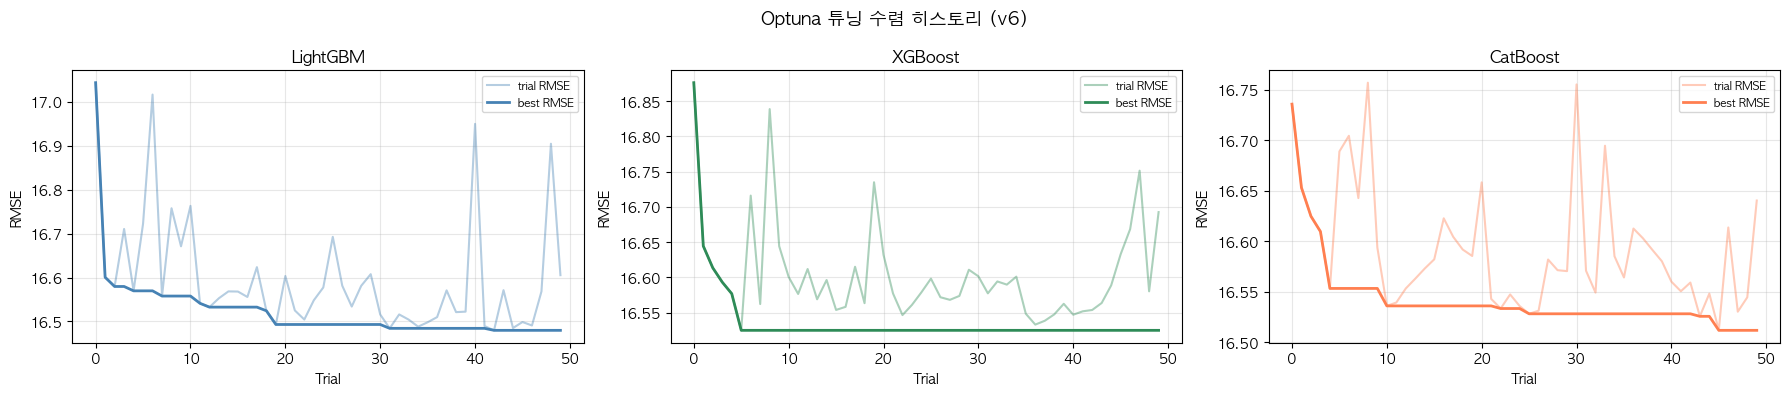

In [8]:
print('=' * 50)
print('Optuna 튜닝 결과 요약')
print('=' * 50)
print(f'LGB Best RMSE (3-Fold): {lgb_study.best_value:.4f}')
print(f'XGB Best RMSE (3-Fold): {xgb_study.best_value:.4f}')
print(f'CAT Best RMSE (3-Fold): {cat_study.best_value:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, study, name, color in zip(
    axes,
    [lgb_study, xgb_study, cat_study],
    ['LightGBM', 'XGBoost', 'CatBoost'],
    ['steelblue', 'seagreen', 'coral']
):
    vals = [t.value for t in study.trials if t.value is not None]
    best = [min(vals[:i+1]) for i in range(len(vals))]
    ax.plot(vals, alpha=0.4, color=color, label='trial RMSE')
    ax.plot(best, color=color, linewidth=2, label='best RMSE')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Optuna 튜닝 수렴 히스토리 (v6)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. 최적 파라미터로 5-Fold 최종 학습 (모델 저장)

In [9]:
gkf5 = GroupKFold(n_splits=N_FOLD)

def run_cv_save_models(model_fn, model_name, fit_kwargs_fn=None):
    oof    = np.zeros(len(X))
    models = []
    for fold, (tr_idx, val_idx) in enumerate(gkf5.split(X, y, groups)):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        model = model_fn()
        kw    = fit_kwargs_fn(X_val, y_val) if fit_kwargs_fn else {}
        model.fit(X_tr, y_tr, **kw)
        oof[val_idx] = model.predict(X_val)
        models.append(model)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {rmse(y_val, oof[val_idx]):.4f}')
    total = rmse(y, oof)
    print(f'  [{model_name}] OOF RMSE: {total:.4f}\n')
    return oof, models, total

print('=== LightGBM ===')
lgb_oof, lgb_models, lgb_score = run_cv_save_models(
    lambda: LGBMRegressor(**lgb_best), 'LGB',
    lambda xv, yv: {'eval_set': [(xv, yv)],
                    'callbacks': [lgb.early_stopping(100, verbose=False),
                                  lgb.log_evaluation(500)]})

=== LightGBM ===
[500]	valid_0's l2: 302.962
  [LGB] Fold 1  RMSE: 17.3718
[500]	valid_0's l2: 277.367
  [LGB] Fold 2  RMSE: 16.6053
[500]	valid_0's l2: 241.651
  [LGB] Fold 3  RMSE: 15.5064
[500]	valid_0's l2: 310.779
  [LGB] Fold 4  RMSE: 17.6113
[500]	valid_0's l2: 236.327
  [LGB] Fold 5  RMSE: 15.3626
  [LGB] OOF RMSE: 16.5174



In [10]:
print('=== XGBoost ===')
xgb_oof, xgb_models, xgb_score = run_cv_save_models(
    lambda: XGBRegressor(**xgb_best), 'XGB',
    lambda xv, yv: {'eval_set': [(xv, yv)], 'verbose': False})

=== XGBoost ===
  [XGB] Fold 1  RMSE: 17.3734
  [XGB] Fold 2  RMSE: 16.6317
  [XGB] Fold 3  RMSE: 15.5289
  [XGB] Fold 4  RMSE: 17.6226
  [XGB] Fold 5  RMSE: 15.3998
  [XGB] OOF RMSE: 16.5367



In [11]:
print('=== CatBoost ===')
cat_oof, cat_models, cat_score = run_cv_save_models(
    lambda: CatBoostRegressor(**cat_best), 'CAT',
    lambda xv, yv: {'eval_set': (xv, yv)})

=== CatBoost ===
  [CAT] Fold 1  RMSE: 17.3323
  [CAT] Fold 2  RMSE: 16.6781
  [CAT] Fold 3  RMSE: 15.4557
  [CAT] Fold 4  RMSE: 17.6498
  [CAT] Fold 5  RMSE: 15.1851
  [CAT] OOF RMSE: 16.4897



## 8. Optuna 앙상블 가중치 최적화

In [12]:
def ens_objective(trial):
    w1 = trial.suggest_float('w_lgb', 0.0, 1.0)
    w2 = trial.suggest_float('w_xgb', 0.0, 1.0)
    w3 = trial.suggest_float('w_cat', 0.0, 1.0)
    s  = w1 + w2 + w3
    if s < 1e-6: return 1e9
    ens = (w1*lgb_oof + w2*xgb_oof + w3*cat_oof) / s
    return rmse(y, ens)

ens_study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
ens_study.optimize(ens_objective, n_trials=500, show_progress_bar=True)

bw    = ens_study.best_params
total = bw['w_lgb'] + bw['w_xgb'] + bw['w_cat']
w_lgb = bw['w_lgb'] / total
w_xgb = bw['w_xgb'] / total
w_cat = bw['w_cat'] / total

ens_oof   = w_lgb*lgb_oof + w_xgb*xgb_oof + w_cat*cat_oof
ens_score = rmse(y, ens_oof)

print('=' * 50)
print(f'LGB  OOF RMSE : {lgb_score:.4f}  (가중치: {w_lgb:.4f})')
print(f'XGB  OOF RMSE : {xgb_score:.4f}  (가중치: {w_xgb:.4f})')
print(f'CAT  OOF RMSE : {cat_score:.4f}  (가중치: {w_cat:.4f})')
print(f'앙상블 OOF RMSE: {ens_score:.4f}')
print(f'v5 대비 개선   : {16.4661 - ens_score:+.4f}')

  0%|          | 0/500 [00:00<?, ?it/s]

LGB  OOF RMSE : 16.5174  (가중치: 0.3451)
XGB  OOF RMSE : 16.5367  (가중치: 0.1447)
CAT  OOF RMSE : 16.4897  (가중치: 0.5102)
앙상블 OOF RMSE: 16.4383
v5 대비 개선   : +0.0278


## 9. Test Autoregressive 추론

In [13]:
def ensemble_predict(X_df):
    pred = np.zeros(len(X_df))
    for m in lgb_models: pred += w_lgb * m.predict(X_df) / N_FOLD
    for m in xgb_models: pred += w_xgb * m.predict(X_df) / N_FOLD
    for m in cat_models: pred += w_cat * m.predict(X_df) / N_FOLD
    return pred


test_work  = test.copy()
test_preds = np.zeros(len(test_work))
pred_hist  = {sc: [] for sc in test_work['scenario_id'].unique()}

print('Autoregressive 추론 시작...')
for step in range(N_STEPS):
    step_mask = test_work['time_step'] == step
    step_idx  = test_work.index[step_mask]
    sc_vals   = test_work.loc[step_idx, 'scenario_id'].values

    for idx, sc in zip(step_idx, sc_vals):
        hist = pred_hist[sc]
        n    = len(hist)
        if n >= 1:
            test_work.at[idx, 'target_lag1']       = hist[-1]
            test_work.at[idx, 'target_roll_mean3']  = np.mean(hist[-min(3, n):])
            test_work.at[idx, 'target_roll_mean5']  = np.mean(hist[-min(5, n):])
        if n >= 2:
            test_work.at[idx, 'target_lag2'] = hist[-2]
        if n >= 3:
            test_work.at[idx, 'target_lag3']      = hist[-3]
            test_work.at[idx, 'target_roll_std3']  = np.std(hist[-3:])

    step_pred              = ensemble_predict(test_work.loc[step_idx, feat_cols])
    test_preds[step_idx]   = step_pred

    for sc, pred in zip(sc_vals, step_pred):
        pred_hist[sc].append(pred)

    if (step + 1) % 5 == 0:
        print(f'  Step {step+1:2d}/{N_STEPS} 완료')

print('추론 완료!')

Autoregressive 추론 시작...
  Step  5/25 완료
  Step 10/25 완료
  Step 15/25 완료
  Step 20/25 완료
  Step 25/25 완료
추론 완료!


## 10. 버전별 성능 비교 및 제출 파일 생성

버전별 OOF RMSE 비교
  v2 (Optuna 튜닝)                     : 21.2717  (+4.8056 vs v5)
  v5 (타겟 lag + v2 params)            : 16.4661  (+0.0000 vs v5)
  v6 LGB                             : 16.5174  (+0.0513 vs v5)
  v6 XGB                             : 16.5367  (+0.0706 vs v5)
  v6 CAT                             : 16.4897  (+0.0236 vs v5)
✓ v6 앙상블 (Optuna 가중)                 : 16.4383  (-0.0278 vs v5)


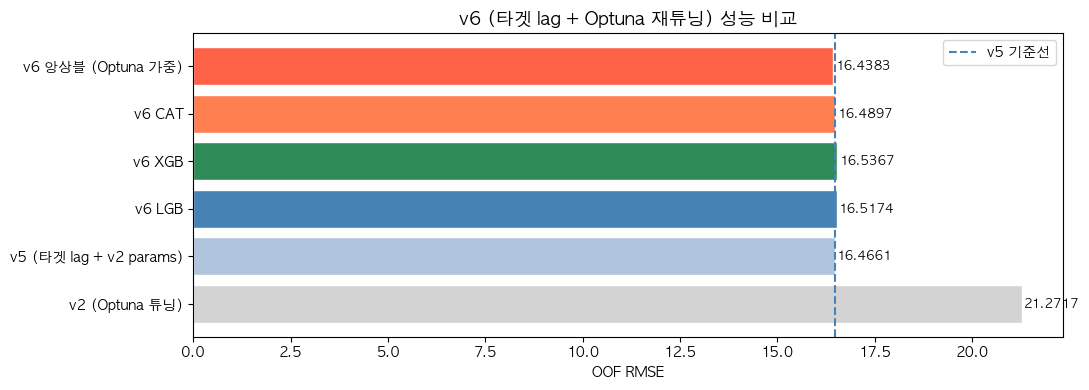

In [14]:
print('=' * 55)
print('버전별 OOF RMSE 비교')
print('=' * 55)
results = {
    'v2 (Optuna 튜닝)':          21.2717,
    'v5 (타겟 lag + v2 params)': 16.4661,
    'v6 LGB':                    lgb_score,
    'v6 XGB':                    xgb_score,
    'v6 CAT':                    cat_score,
    'v6 앙상블 (Optuna 가중)':   ens_score,
}
for name, score in results.items():
    delta = score - 16.4661
    mark  = '✓' if delta < 0 else ' '
    print(f'{mark} {name:35s}: {score:.4f}  ({delta:+.4f} vs v5)')

colors = ['lightgray', 'lightsteelblue',
          'steelblue', 'seagreen', 'coral', 'tomato']
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(list(results.keys()), list(results.values()),
               color=colors, edgecolor='white')
for bar, score in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)
ax.axvline(16.4661, color='steelblue', linestyle='--', lw=1.5, label='v5 기준선')
ax.set_xlabel('OOF RMSE')
ax.set_title('v6 (타겟 lag + Optuna 재튜닝) 성능 비교', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
submission = pd.read_csv('./open/sample_submission.csv')
submission[TARGET] = test_preds
submission.to_csv('./submission_v6.csv', index=False)

print(f'submission_v6.csv 저장 완료  (OOF RMSE: {ens_score:.4f})')
print(f'v5 대비 개선: {16.4661 - ens_score:+.4f}')
print(submission[TARGET].describe().round(4))

submission_v6.csv 저장 완료  (OOF RMSE: 16.4383)
v5 대비 개선: +0.0278
count    50000.0000
mean        20.1808
std         13.1987
min          1.8462
25%          7.2565
50%         18.6198
75%         31.9062
max         72.3775
Name: avg_delay_minutes_next_30m, dtype: float64
